### Casual Impact란?

- 구글이 발표한 https://github.com/google/CausalImpact R 패키지
- https://playinpap.github.io/causalimpact-covid19/를 Copy함 (중복 내용 지우고, 해석 설명만 추가)

In [1]:
%load_ext rpy2.ipython

/Users/naeae/Documents/GitHub/DataAnalyticsTools/.venv/lib/python3.14/site-packages/rpy2/ipython/rmagic.py:96: UserWarning: The Python package `pandas` is strongly recommended when using `rpy2.ipython`. Unfortunately it could not be loaded, as we did not manage to load `numpy` in the first place (error: No module named 'numpy').
  warnings.warn('The Python package `pandas` is strongly '


### 예제 데이터를 만들어서 실행해보자.

- 필요한 변수
y   : outcome (target time series)
x1,x2,x3 : control time series
- 주의사항
    - 데이터 프레임을 만들때 유의하자. 첫번째 열을 y로 인지한다.
- 개념
    - 데이터가 분리되기 이전 시점(처리 이전)을 기준으로 나머지 x1...xn의 데이터로 y를 예측한다.
    - 데이터가 분리된 이후 시점(처리 이후)을 기준으로 미래를 예측하고, 실제 증가량과 예측값의 편차를 ATE로 보는 분석법이다.

In [24]:
%%R
# 시계열 길이
n <- 100

# control time series
x1 <- rnorm(n)
x2 <- rnorm(n)
x3 <- rnorm(n)

# outcome 생성
y <- 0.5 * x1 - 0.3 * x2 + 0.2 * x3 + rnorm(n)

# intervention 효과 추가
y[71:100] <- y[71:100] + 5

# 데이터 프레임
data <- cbind(y, x1, x2, x3)
head(data)

              y          x1          x2         x3
[1,]  0.5271173  0.68283627  0.80906097  0.2438599
[2,]  1.3336790 -0.66440549  0.09206635 -0.4442285
[3,] -0.7656042 -0.78655013  1.26186527 -0.6085726
[4,] -0.9651892 -0.07555162  0.68932035 -0.4904730
[5,] -0.7404489 -0.57357410 -1.64495570 -0.6134713
[6,]  1.3561935  1.88971131  0.60451617  0.8870181


전환구간을 설정해주고 모델을 돌리자.
- 1 ~ 70   : intervention 이전
- 71 ~ 100 : intervention 이후

Posterior inference {CausalImpact}

                         Average             Cumulative       
Actual                   5.5                 164.1            
Prediction (s.d.)        0.26 (0.21)         7.75 (6.45)      
95% CI                   [-0.15, 0.69]       [-4.43, 20.84]   
                                                              
Absolute effect (s.d.)   5.2 (0.21)          156.3 (6.45)     
95% CI                   [4.8, 5.6]          [143.2, 168.5]   
                                                              
Relative effect (s.d.)   2890% (36936%)      2890% (36936%)   
95% CI                   [-13320%, 17337%]   [-13320%, 17337%]

Posterior tail-area probability p:   0.001
Posterior probability of an effect:  99.9%

For more details, type: summary(impact, "report")

Analysis report {CausalImpact}


During the post-intervention period, the response variable had an average value of approx. 5.47. In the absence of an intervention, we would have expected an aver

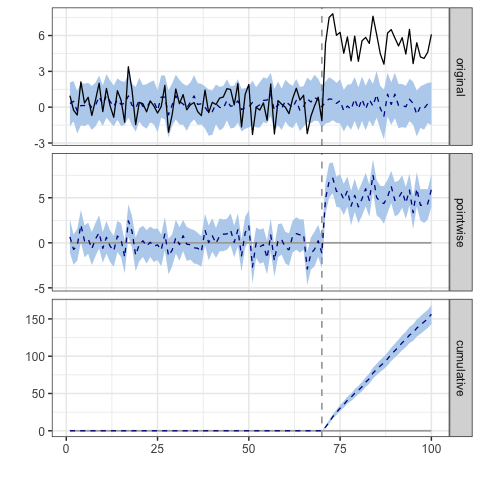

In [23]:
%%R
pre.period <- c(1, 70)
post.period <- c(71, 100)

impact <- CausalImpact(data, pre.period, post.period)
summary(impact)

# 해석 결과를 포맷팅 하고 싶을때
summary(impact, "report")

# 시각화
plot(impact)

### 아래 케이스 이 예제를 실 사례에 적용해본 예시임. (pap 블로그 글 카피)
- 이런식으로 응용할 수 있음
- https://playinpap.github.io/causalimpact-covid19/의 예제를 그냥 실행해본 결과

In [5]:
%%R
library(coronavirus) #데이터를 불러오는 패키지
library(CausalImpact)
library(tidyverse) 
library(lubridate) #날짜 관련 라이브러리

## 데이터 불러오기
data(coronavirus)
df = coronavirus

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::first()  masks xts::first()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::last()   masks xts::last()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [8]:
%%R
df_kr =  df %>% 
  filter(str_detect(country, 'Korea'), type =='confirmed')

- date: YYYY-MM-DD 포맷의 날짜
- province: 주의 이름
- country: 나라 이름
- lat: 위도
- long: 경도
- type: confirmed (확진) / death (사망) / recovered (회복) 중 하나
- cases: 해당 날짜의 type에 따른 사람 수
- uid: 국가 코드
- iso2: 두 글자로 이뤄진 국가 코드
- iso3: 세 글자로 이뤄진 국가 코드
- code3: UN 국가 코드
- combined_key: 국가와 주 명
- population: 국가의 인구
- continent_name: 대륙 명
- continent_code: 대륙 코드

In [10]:
%%R
df_kr

           date province      country      lat     long      type  cases uid
1    2020-01-22     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
2    2020-01-23     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
3    2020-01-24     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
4    2020-01-25     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
5    2020-01-26     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
6    2020-01-27     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
7    2020-01-28     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
8    2020-01-29     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
9    2020-01-30     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
10   2020-01-31     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
11   2020-02-01     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA
12   2020-02-02     <NA> Korea, North 40.33990 127.5101 confirmed      0  NA

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by date and country.
ℹ Output is grouped by date.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(date, country))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.


In addition: Warning message:
In scale_x_date(date_labels = "%Y-%m", date_breaks = "1 month") :
  A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.


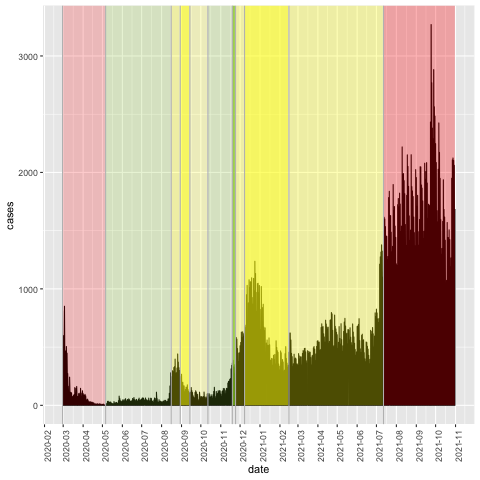

In [13]:
%%R
# 한국 데이터만 뽑아보자
df_kr =  df %>% 
  group_by(date,country) %>% 
  filter(str_detect(country, 'Korea')
         ,type =='confirmed') %>% 
  filter(date >= as_date("2020-02-29") & date <= as_date("2021-10-31")) %>%
  summarise(cases=sum(cases))

# 기본 확진자수 
covid_plot = ggplot(df_kr, aes(x=date, y=cases)) +
  geom_line()+
  # scale_x_continuous(n.breaks=10)+
  scale_x_date(date_labels="%Y-%m",date_breaks = "1 month")+
  theme(axis.text.x = element_text(angle=90))

# 거리두기 정책 날짜
 covid_policy_plot = 
  covid_plot+
  #---------------------------------------------------------------------------------------------
  # 3단계 화: 20.06.28 ~ 20.11.06
  geom_ribbon(data=subset(df_kr, as_date("2020-02-29") <= date & date <= as_date("2020-05-05")), 
            aes(ymin=0,ymax=Inf), fill="red", alpha=0.2) + # 3단계
  geom_ribbon(data=subset(df_kr, as_date("2020-05-06") <= date & date <= as_date("2020-08-15")), 
              aes(ymin=0,ymax=Inf), fill="yellowgreen", alpha=0.2) + # 1단계
  geom_ribbon(data=subset(df_kr, as_date("2020-08-16") <= date & date <= as_date("2020-08-29")), 
              aes(ymin=0,ymax=Inf), fill="yellow", alpha=0.3) + # 2단계
  geom_ribbon(data=subset(df_kr, as_date("2020-08-30") <= date & date <= as_date("2020-09-13")), 
              aes(ymin=0,ymax=Inf), fill="yellow", alpha=0.6) + # 2.5단계
  geom_ribbon(data=subset(df_kr, as_date("2020-09-14") <= date & date <= as_date("2020-10-11")), 
              aes(ymin=0,ymax=Inf), fill="yellow", alpha=0.2) + # 2단계
  geom_ribbon(data=subset(df_kr, as_date("2020-10-12") <= date & date <= as_date("2020-11-18")), 
              aes(ymin=0,ymax=Inf), fill="yellowgreen", alpha=0.2) + # 1단계 (전국)
  #---------------------------------------------------------------------------------------------
  # 5단계 화: 20.11.07 ~ 21.07.11
  geom_ribbon(data=subset(df_kr, as_date("2020-11-19") <= date & date <= as_date("2020-11-23")), 
              aes(ymin=0,ymax=Inf), fill="yellowgreen", alpha=0.8) + # 1.5단계
  geom_ribbon(data=subset(df_kr, as_date("2020-11-24") <= date & date <= as_date("2020-12-07")), 
              aes(ymin=0,ymax=Inf), fill="yellow", alpha=0.3) + # 2단계
  geom_ribbon(data=subset(df_kr, as_date("2020-12-08") <= date & date <= as_date("2021-02-14")), 
              aes(ymin=0,ymax=Inf), fill="yellow", alpha=0.6) + # 2.5단계
  geom_ribbon(data=subset(df_kr, as_date("2021-02-15") <= date & date <= as_date("2021-07-11")), 
              aes(ymin=0,ymax=Inf), fill="yellow", alpha=0.3) + # 2단계
  #---------------------------------------------------------------------------------------------
  # 4단계 화: 20.07.11 ~ 21.10.31
  geom_ribbon(data=subset(df_kr, as_date("2021-07-12") <= date & date <= as_date("2021-10-31")), 
              aes(ymin=0,ymax=Inf), fill="red", alpha=0.3) + # 4단계
  #---------------------------------------------------------------------------------------------
  geom_vline(xintercept=sapply(c("2020-02-29","2020-05-06","2020-08-16","2020-08-30","2020-09-14"
    ,"2020-10-12", "2020-11-19", "2020-11-24", "2020-12-08", "2021-02-15","2021-07-12"),
                               as_date), color = "gray",size=.5)
print(covid_policy_plot)

In [14]:
%%R
start_date = as_date("2020-01-22")
treat_date = as_date("2020-02-28")
treat_date_p1 = as_date(treat_date) + 1 # 그 다음날
end_date   = as_date("2020-05-01")

# 날짜별, 국가별로 group_by하여 확진자수를 더해주고 컬럼별로 국가 정보를 담고 있도록 만들어주기
df_total = df %>% 
  filter(country %in% c('Korea, South','Canada','Greece','US','Japan'), type == 'confirmed') %>% 
  filter(date >= start_date, date <= end_date) %>% 
  group_by(date, country) %>% 
  summarise(cases=sum(cases)) %>% 
  spread(country, cases) %>%     # long to wide
  select(1,5,2,3,4,6) %>%        # 순서 바꿔주기
  rename(Korea = `Korea, South`) # 컬럼명을 Korea, South -> Korea로 바꿔주기

# zoo 형태로 만들어주기
df_causal = zoo(as.data.frame(df_total[,c(2:6)]), df_total$date)
print(df_causal)

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by date and country.
ℹ Output is grouped by date.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(date, country))` for per-operation grouping
  (`?dplyr::dplyr_by`) instead.
           Korea Canada Greece Japan    US
2020-01-22     1      0      0     2     1
2020-01-23     0      2      0     0     0
2020-01-24     1      1      0     0     1
2020-01-25     0      0      0     0     0
2020-01-26     1      0      0     2     3
2020-01-27     1      0      0     0     0
2020-01-28     0      1      0     3     0
2020-01-29     0      0      0     0     1
2020-01-30     0      0      0     4     0
2020-01-31     7      0      0     4     2
2020-02-01     1      0      0     5     0
2020-02-02     3      0      0     0     0
2020-02-03     0      0      0     0     3
2020-02-04     1      1      0     2     0
2020-02-05     3      1      0     1     0
2020-02-06     4     

R callback write-console: In addition:   
R callback write-console: Warning message:
  
R callback write-console: In scale_x_date() :  
R callback write-console:  A <numeric> value was passed to a Date scale.
ℹ The value was converted to a <Date> object.
  


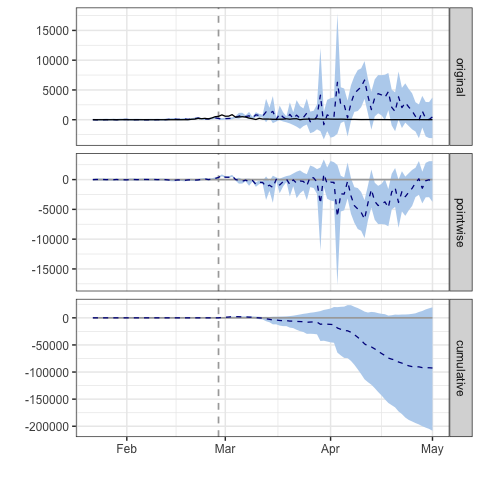

In [15]:
%%R
# CausalImpact 적용하기
causal_impact = CausalImpact(data = df_causal
                             , pre.period = as_date(c(start_date, treat_date))
                             , post.period = as_date(c(treat_date_p1, end_date)))

plot(causal_impact)

In [17]:
%%R
summary(causal_impact)

Posterior inference {CausalImpact}

                         Average         Cumulative      
Actual                   134             8443            
Prediction (s.d.)        1603 (941)      100987 (59283)  
95% CI                   [-174, 3441]    [-10958, 216798]
                                                         
Absolute effect (s.d.)   -1469 (941)     -92544 (59283)  
95% CI                   [-3307, 308]    [-208355, 19401]
                                                         
Relative effect (s.d.)   -102% (351%)    -102% (351%)    
95% CI                   [-136%, -48%]   [-136%, -48%]   

Posterior tail-area probability p:   0.0603
Posterior probability of an effect:  94%

For more details, type: summary(impact, "report")

